***PREPROCESSING***

In [ ]:
import os
import glob
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (auc, average_precision_score, classification_report,
                             cohen_kappa_score, confusion_matrix, f1_score,
                             precision_recall_curve, roc_curve)
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import label_binarize

In [1]:
USE_CACHE = True   # False only if you change the features and must re-extract

if USE_CACHE:
    features_clean  = pd.read_csv("/kaggle/input/datasets/alexdrapant/walch-features-csv/walch_features.csv")
    dreamt_clean = pd.read_csv("/kaggle/input/datasets/alexdrapant/dreamt-features-csv/dreamt_features.csv")
else:
    WALCH_DIR = "/kaggle/input/datasets/msarmi9/walch-apple-watch-sleep-dataset/walch-apple-watch"
    DREAMT_DATA_DIR = "/kaggle/input/datasets/alexdrapant/dreamt/dreamt-dataset-for-real-time-sleep-stage-estimation-using-multisensor-wearable-technology-1.0.1/data"

***WALCH DATASET***

In [2]:
EPOCH_SEC = 30

# Mapping of Walch integer stages -> 3 classes
# Walch uses: 0=Wake, 1=N1, 2=N2, 3=N3, 5=REM, -1=unscored
# We collapse N1+N2+N3 -> NREM, as required by the task
STAGE_MAP = {
    0: "Wake",
    1: "NREM",
    2: "NREM",
    3: "NREM",
    5: "REM"
    # -1 is not present -> it is discarded automatically
}

# String -> integer mapping for the models
LABEL_MAP = {"Wake": 0, "NREM": 1, "REM": 2}

print("Constants defined:")
print(f"  EPOCH_SEC = {EPOCH_SEC}s")
print(f"  Target classes: {LABEL_MAP}")

Constants defined:
  EPOCH_SEC = 30s
  Target classes: {'Wake': 0, 'NREM': 1, 'REM': 2}


In [3]:
if not USE_CACHE:
    label_files = sorted(glob.glob(f"{WALCH_DIR}/labels/*_labeled_sleep.csv"))
    all_ids = [os.path.basename(f).replace("_labeled_sleep.csv", "") for f in label_files]
    
    print(f"Total subjects: {len(all_ids)}")
    print(all_ids)

In [4]:
def read_two_column_file(filepath):
    """Read the Walch CSV files with a header and convert them to numeric."""
    try:
        df = pd.read_csv(filepath, sep=",", low_memory=False)
        if df.shape[1] == 1:
            df = pd.read_csv(filepath, sep=r"\s+", engine="python", low_memory=False)
        # Convert to numeric, NaN for non-convertible values
        df = df.apply(pd.to_numeric, errors="coerce")
        df = df.dropna().reset_index(drop=True)
        return df
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

def load_subject_raw(sid, walch_dir):
    acc_path = f"{walch_dir}/motion/{sid}_acceleration.csv"
    hr_path  = f"{walch_dir}/heart_rate/{sid}_heartrate.csv"
    lab_path = f"{walch_dir}/labels/{sid}_labeled_sleep.csv"

    acc = read_two_column_file(acc_path)
    hr  = read_two_column_file(hr_path)
    lab = read_two_column_file(lab_path)

    if acc is None or hr is None or lab is None:
        raise FileNotFoundError(f"Missing file for subject {sid}")

    # Actual column names from the files
    # motion:     timestamp, x, y, z
    # heart_rate: timestamp, hr
    # labels:     epoch, label  <- different from the others!
    acc.columns = ["t", "x", "y", "z"]
    hr.columns  = ["t", "hr"]
    lab.columns = ["t", "stage"]   # rename epoch->t and label->stage for consistency

    acc = acc.sort_values("t").reset_index(drop=True)
    hr  = hr.sort_values("t").reset_index(drop=True)
    lab = lab.sort_values("t").reset_index(drop=True)

    return acc, hr, lab
    
if not USE_CACHE:
    # Test
    sid_test = all_ids[0]
    acc, hr, lab = load_subject_raw(sid_test, WALCH_DIR)
    
    print(f"Subject: {sid_test}")
    print(f"\nACCELEROMETER: {acc.shape}")
    print(acc.head(3))
    print(f"\nHEART RATE: {hr.shape}")
    print(hr.head(3))
    print(f"\nLABELS: {lab.shape}")
    print(lab.head(3))
    print(f"\nUnique stages: {sorted(lab['stage'].unique())}")
    print(f"\nTimestamp range ACC:  {acc['t'].min():.1f}s  ->  {acc['t'].max():.1f}s")
    print(f"Timestamp range LAB:  {lab['t'].min():.1f}s  ->  {lab['t'].max():.1f}s")

In [5]:
def extract_features_subject(sid, walch_dir):
    """
    For one subject, extract a feature vector for every 30s epoch.
    Returns a DataFrame where each row = one epoch.

    Extracted features (14 in total):
      ACC (6): enmo_mean, enmo_std, acc_mag_std, acc_count,
               angle_mean, angle_std
      HR  (6): hr_mean, hr_std, hr_min, hr_max, hr_range, hr_mssd
      Time (2): epoch_progress, angle_delta   <- added LATER by add_context_features
    """
    acc, hr, lab = load_subject_raw(sid, walch_dir)

    # Keep only the sleep period (t >= 0)
    acc = acc[acc["t"] >= 0].reset_index(drop=True)
    hr  = hr[hr["t"]  >= 0].reset_index(drop=True)

    # Remove duplicate HR readings
    hr = hr.drop_duplicates(subset=["t"]).reset_index(drop=True)

    # Numpy arrays for fast operations
    acc_t   = acc["t"].to_numpy()
    acc_xyz = acc[["x", "y", "z"]].to_numpy()
    hr_t    = hr["t"].to_numpy()
    hr_v    = hr["hr"].to_numpy()

    # Total number of valid epochs (needed for epoch_progress)
    valid_epochs = [r for _, r in lab.iterrows() if int(r["stage"]) in STAGE_MAP]
    n_valid = len(valid_epochs)

    rows = []
    for epoch_idx, row in enumerate(valid_epochs):
        t_start = row["t"]
        t_end   = t_start + EPOCH_SEC
        stage   = int(row["stage"])

        # Slice the samples falling inside this epoch
        a0, a1 = np.searchsorted(acc_t, [t_start, t_end])
        h0, h1 = np.searchsorted(hr_t,  [t_start, t_end])

        acc_epoch = acc_xyz[a0:a1]   # shape: (n_samples, 3)
        hr_epoch  = hr_v[h0:h1]      # shape: (m_samples,)

        # ── Feature ACC ─────────────────────────────────────────────────────
        if len(acc_epoch) > 0:
            ax, ay, az = acc_epoch[:,0], acc_epoch[:,1], acc_epoch[:,2]
            mag  = np.sqrt(ax**2 + ay**2 + az**2)
            enmo = np.clip(mag - 1.0, 0, None)

            # Wrist angle relative to the vertical (in degrees).
            # During sleep the wrist is almost still; the variations
            # signal movements or posture changes.
            angle = np.degrees(np.arctan2(az, np.sqrt(ax**2 + ay**2)))

            acc_feats = {
                "enmo_mean"  : enmo.mean(),
                "enmo_std"   : enmo.std(),
                "acc_mag_std": mag.std(),
                "acc_count"  : float((enmo > 0.05).sum()),
                "angle_mean" : angle.mean(),   # mean wrist position
                "angle_std"  : angle.std(),    # how much it swings within the epoch
                #"enmo_max"   : enmo.max(),                    # <-- NEW
                #"enmo_p90"   : np.percentile(enmo, 90),       # <-- NEW
            }
        else:
            acc_feats = {k: np.nan for k in
                        ["enmo_mean","enmo_std","acc_mag_std","acc_count",
                         "angle_mean","angle_std"
                         #"enmo_max","enmo_p90"
                        ]}

        # ── Feature HR ──────────────────────────────────────────────────────
        if len(hr_epoch) > 0:
            hr_clean = hr_epoch[(hr_epoch > 20) & (hr_epoch < 220)]
            if len(hr_clean) > 1:
                d = np.diff(hr_clean)
                hr_feats = {
                    "hr_mean" : hr_clean.mean(),
                    "hr_std"  : hr_clean.std(),
                    "hr_min"  : hr_clean.min(),
                    "hr_max"  : hr_clean.max(),
                    "hr_range": hr_clean.max() - hr_clean.min(),
                    "hr_mssd" : np.sqrt(np.mean(d**2)),
                    #"hr_cv": (hr_clean.std() / hr_clean.mean()) if hr_clean.mean() > 0 else 0.0,   # <-- NEW
                }
            else:
                hr_feats = {
                    "hr_mean" : hr_clean[0] if len(hr_clean)==1 else np.nan,
                    "hr_std"  : np.nan, "hr_min" : np.nan,
                    "hr_max"  : np.nan, "hr_range": np.nan, "hr_mssd": np.nan,
                }
        else:
            hr_feats = {k: np.nan for k in
                       ["hr_mean","hr_std","hr_min","hr_max","hr_range","hr_mssd"]}

        # ── Position within the night ────────────────────────────────────────────
        # 0.0 = first epoch, 1.0 = last epoch of the night.
        # REM is concentrated late in the night: this feature helps a lot.
        epoch_progress = epoch_idx / max(n_valid - 1, 1)

        # ── Assemble the row ────────────────────────────────────────────────────
        feat_row = {
            "subject_id"    : sid,
            "epoch"         : int(t_start // EPOCH_SEC),
            "t_start"       : t_start,
            "stage_orig"    : stage,
            "label_str"     : STAGE_MAP[stage],
            "label"         : LABEL_MAP[STAGE_MAP[stage]],
            "epoch_progress" : epoch_progress,
            **acc_feats,
            **hr_feats,
        }
        rows.append(feat_row)

    return pd.DataFrame(rows)

if not USE_CACHE:
    # Test on a single subject
    df_test = extract_features_subject(all_ids[0], WALCH_DIR)
    
    print(f"Shape: {df_test.shape}")
    print(f"First rows:")
    print(df_test[["epoch","epoch_progress","angle_mean","angle_std","hr_mean","label_str"]].head())
    print(f"Class distribution:")
    print(df_test["label_str"].value_counts())
    print(f"Missing values per column:")
    print(df_test.isna().sum())


In [6]:
if not USE_CACHE:
    # Extract features for all subjects
    all_dfs = []
    for sid in all_ids:
        try:
            df_sid = extract_features_subject(sid, WALCH_DIR)
            all_dfs.append(df_sid)
            print(f"✓ {sid}: {len(df_sid)} epoch | classes: {df_sid['label_str'].value_counts().to_dict()}")
        except Exception as e:
            print(f"✗ {sid}: ERROR -> {e}")
    
    # Concatenate everything
    features_df = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n{'='*50}")
    print(f"COMPLETE DATASET")
    print(f"Total epochs:    {len(features_df)}")
    print(f"Subjects:        {features_df['subject_id'].nunique()}")
    print(f"\nGlobal class distribution:")
    print(features_df["label_str"].value_counts())
    print(f"\nGlobal missing values:")
    print(features_df.isna().sum())

In [7]:
# The 14 base features (extracted epoch-by-epoch)
# Note: angle_delta and the rolling features are added LATER by add_context_features
FEATURE_COLS_BASE = [
    "enmo_mean", "enmo_std", "acc_mag_std", "acc_count",
    "angle_mean", "angle_std", #"enmo_max", "enmo_p90",       # <-- 2 new ACC
    "hr_mean", "hr_std", "hr_min", "hr_max", "hr_range", "hr_mssd", #"hr_cv",   # <-- 1 new HR
    "epoch_progress",
]

# Final list of all features used by the models
FEATURE_COLS = FEATURE_COLS_BASE + [
    "angle_delta",
    "enmo_mean_roll5", "enmo_std_roll5",
    "hr_mean_roll5",   "hr_std_roll5",
]

N_FEATURES = len(FEATURE_COLS)   # 18

print(f"Total features: {N_FEATURES}")
print(f"Names: {FEATURE_COLS}")
print()
    

Total features: 18
Names: ['enmo_mean', 'enmo_std', 'acc_mag_std', 'acc_count', 'angle_mean', 'angle_std', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'hr_mssd', 'epoch_progress', 'angle_delta', 'enmo_mean_roll5', 'enmo_std_roll5', 'hr_mean_roll5', 'hr_std_roll5']



In [8]:
def add_context_features(df):
    """
    Add features that look at the neighbouring epochs.

    Why are they needed?
    Sleep does not change every 30 seconds: it stays in the same stage
    for blocks of minutes. A moving window captures this inertia and
    helps the Random Forest most of all, which otherwise sees every
    epoch in isolation.

    Features added (5 new ones):
      angle_delta     : absolute angle change with respect to the previous epoch.
                        A large jump = movement or posture change.
      enmo_mean_roll5 : mean ENMO over the 5 surrounding epochs (+-2 epoch window, 2.5 min).
      enmo_std_roll5  : ENMO standard deviation over the same window.
      hr_mean_roll5   : mean HR over the 5 surrounding epochs.
      hr_std_roll5    : HR std over the same window.

    Total number of features after this function: 18.

    IMPORTANT: this function must be called AFTER impute_and_normalize,
    because it works on values that are already cleaned and z-scored.
    """
    df = df.copy()

    for sid in df["subject_id"].unique():
        mask = df["subject_id"] == sid

        # angle_delta: how much the angle changed with respect to the previous epoch
        df.loc[mask, "angle_delta"] = (
            df.loc[mask, "angle_mean"].diff().abs()
        )

        # Rolling over a 5-epoch window (center=True: 2 before + current + 2 after)
        for col, stat in [("enmo_mean", "mean"), ("enmo_std", "mean"),
                          ("hr_mean",   "mean"), ("hr_std",   "mean")]:
            rolled = (df.loc[mask, col]
                        .rolling(window=5, center=True, min_periods=1))
            suffix = "roll5"
            new_col = f"{col}_{suffix}"
            df.loc[mask, new_col] = getattr(rolled, stat)()

    # Impute the NaNs introduced by diff() and rolling (first/last epoch)
    context_cols = ["angle_delta",
                    "enmo_mean_roll5", "enmo_std_roll5",
                    "hr_mean_roll5",   "hr_std_roll5"]
    for col in context_cols:
        df[col] = df.groupby("subject_id")[col].transform(
            lambda s: s.fillna(s.median())
        )

    return df


def impute_and_normalize(df, clip_sigma=3.0):
    """
    1. Impute NaNs with the per-subject median
    2. Per-subject z-score
    3. Clip outliers at +-clip_sigma
    Works on FEATURE_COLS_BASE (without the rolling features, which do not exist yet).
    """
    df = df.copy()

    for sid in df["subject_id"].unique():
        mask = df["subject_id"] == sid

        for col in FEATURE_COLS_BASE:
            median_val = df.loc[mask, col].median()
            df.loc[mask, col] = df.loc[mask, col].fillna(median_val)

            mean_val = df.loc[mask, col].mean()
            std_val  = df.loc[mask, col].std()
            if std_val > 0:
                df.loc[mask, col] = (df.loc[mask, col] - mean_val) / std_val
            else:
                df.loc[mask, col] = 0.0
                
        # Clipping means cutting the values that exceed a given threshold, bringing them back to the threshold itself.
        df.loc[mask, FEATURE_COLS_BASE] = df.loc[mask, FEATURE_COLS_BASE].clip(
            lower=-clip_sigma, upper=clip_sigma
        )

    return df

if not USE_CACHE:
    # Full pipeline: normalize the base features, then add the context ones
    features_normalized = impute_and_normalize(features_df)
    features_clean      = add_context_features(features_normalized)

    # Check
    print("Missing values after the pipeline:")
    print(features_clean[FEATURE_COLS].isna().sum())
    print(f"Range after clipping (base features must lie in [-3, +3]):")
    print(features_clean[FEATURE_COLS].describe().loc[["mean","std","min","max"]].round(3))


In [9]:
if not USE_CACHE:
    features_clean.to_csv("/kaggle/working/walch_features.csv", index=False)
    print("Saved to /kaggle/working/walch_features.csv")
    print(f"Size: {features_clean.shape}")

***DREAMT DATASET — FEATURE EXTRACTION***

In [10]:
# DREAMT stores the stage as TEXT. We collapse N1+N2+N3 -> NREM, as in Walch.
# P (Preparation) and Missing are NOT here -> they are discarded automatically.
STAGE_MAP_DREAMT = {
    "W":  "Wake",
    "N1": "NREM", "N2": "NREM", "N3": "NREM",
    "R":  "REM",
}

# The Empatica E4 accelerometer is documented in units of 1/64 g.
# We convert it to g, so that ENMO (mag - 1.0) has the same meaning as in Walch.
ACC_SCALE = 1.0 / 64.0

# The only 6 columns shared with Walch (we read only these: saves memory)
DREAMT_KEEP = ["TIMESTAMP", "ACC_X", "ACC_Y", "ACC_Z", "HR", "Sleep_Stage"]


def collapse_repeats(values):
    """The E4 repeats the same HR value ~64 times per second.
    We keep a value only when it CHANGES, so the series resembles
    separate real readings (like Walch's irregular HR).
    Without this, hr_std and hr_mssd would almost always be 0."""
    v = np.asarray(values, dtype=float)
    if len(v) == 0:
        return v
    keep = np.concatenate(([True], v[1:] != v[:-1]))
    return v[keep]


def extract_features_dreamt(filepath):
    """
    One row per 30s epoch, with the SAME 13 base features as Walch
    (6 ACC + 6 HR + epoch_progress). The 5 context features are added
    afterwards with add_context_features (the same function used for Walch).
    """
    sid = os.path.basename(filepath).replace("_whole_df.csv", "")
    df  = pd.read_csv(filepath, usecols=DREAMT_KEEP)

    # 1) text stage -> 3 classes; discard P / Missing (they become NaN -> dropna)
    df["label_str"] = df["Sleep_Stage"].map(STAGE_MAP_DREAMT)
    df = df.dropna(subset=["label_str"]).reset_index(drop=True)
    if len(df) == 0:
        return pd.DataFrame()

    # 2) which 30s epoch each row belongs to (TIMESTAMP is in seconds)
    df["epoch"] = (df["TIMESTAMP"] // EPOCH_SEC).astype(int)

    # 3) accelerometer -> g, then magnitude, ENMO and wrist angle
    ax = df["ACC_X"].to_numpy() * ACC_SCALE
    ay = df["ACC_Y"].to_numpy() * ACC_SCALE
    az = df["ACC_Z"].to_numpy() * ACC_SCALE
    df["_mag"]   = np.sqrt(ax**2 + ay**2 + az**2)
    df["_enmo"]  = np.clip(df["_mag"] - 1.0, 0, None)
    df["_angle"] = np.degrees(np.arctan2(az, np.sqrt(ax**2 + ay**2)))

    # Map epoch -> position within the night (0.0 start, 1.0 end)
    epoch_ids = np.sort(df["epoch"].unique())
    n_valid   = len(epoch_ids)
    progress  = {ep: i / max(n_valid - 1, 1) for i, ep in enumerate(epoch_ids)}

    rows = []
    for ep, g in df.groupby("epoch"):
        # Within a 30s epoch the label is constant; mode = safety net
        stage = g["label_str"].mode().iloc[0]

        enmo_ep, mag_ep, angle_ep = (g["_enmo"].to_numpy(),
                                     g["_mag"].to_numpy(),
                                     g["_angle"].to_numpy())
        acc_feats = {
            "enmo_mean"  : enmo_ep.mean(),
            "enmo_std"   : enmo_ep.std(),
            "acc_mag_std": mag_ep.std(),
            "acc_count"  : float((enmo_ep > 0.05).sum()),
            "angle_mean" : angle_ep.mean(),
            "angle_std"  : angle_ep.std(),
            #"enmo_max"   : enmo_ep.max(),                    # <-- NEW
            #"enmo_p90"   : np.percentile(enmo_ep, 90), 
        }

        hr_ep = collapse_repeats(g["HR"].to_numpy())
        hr_ep = hr_ep[(hr_ep > 20) & (hr_ep < 220)]   # physiological range
        if len(hr_ep) > 1:
            d = np.diff(hr_ep)
            hr_feats = {
                "hr_mean": hr_ep.mean(), "hr_std": hr_ep.std(),
                "hr_min" : hr_ep.min(),  "hr_max": hr_ep.max(),
                "hr_range": hr_ep.max() - hr_ep.min(),
                "hr_mssd": np.sqrt(np.mean(d**2)),
                #"hr_cv": (hr_ep.std() / hr_ep.mean()) if hr_ep.mean() > 0 else 0.0,   # <-- NEW
            }
        else:
            hr_feats = {k: np.nan for k in
                        ["hr_mean","hr_std","hr_min","hr_max","hr_range","hr_mssd"]}

        rows.append({
            "subject_id"    : sid,
            "epoch"         : int(ep),
            "t_start"       : float(ep * EPOCH_SEC),
            "stage_orig"    : stage,
            "label_str"     : stage,
            "label"         : LABEL_MAP[stage],
            "epoch_progress": progress[ep],
            **acc_feats, **hr_feats,
        })

    return pd.DataFrame(rows)

if not USE_CACHE:
    # --- Test on a SINGLE subject, to check things before running everything ---
    dreamt_files = sorted(glob.glob(f"{DREAMT_DATA_DIR}/*_whole_df.csv"))
    print(f"DREAMT files found: {len(dreamt_files)}")
    
    df_test = extract_features_dreamt(dreamt_files[0])
    print(f"\nShape (one subject): {df_test.shape}")
    print("\nClass distribution:")
    print(df_test["label_str"].value_counts())
    print("\nFirst rows:")
    print(df_test[["epoch","epoch_progress","angle_mean","hr_mean","hr_std","label_str"]].head())


In [11]:
if not USE_CACHE:
    # ── Extract ALL DREAMT subjects (this can take a few minutes) ──
    dreamt_rows = []
    for i, f in enumerate(dreamt_files):
        d = extract_features_dreamt(f)
        if len(d):
            dreamt_rows.append(d)
        if (i + 1) % 10 == 0 or i == len(dreamt_files) - 1:
            print(f"  [{i+1:3d}/{len(dreamt_files)}] processed")
    
    dreamt_df = pd.concat(dreamt_rows, ignore_index=True)
    print(f"\nTotal epochs: {len(dreamt_df)} | subjects: {dreamt_df['subject_id'].nunique()}")
    print(dreamt_df["label_str"].value_counts())
    
    # ── SAME functions as Walch (defined in the preprocessing cell) ──
    # 1) per-subject z-score normalization, 2) adds the context features
    dreamt_norm  = impute_and_normalize(dreamt_df)
    dreamt_clean = add_context_features(dreamt_norm)
    
    # Save for the cross-dataset experiment (train DREAMT -> test Walch)
    dreamt_clean.to_csv("/kaggle/working/dreamt_features.csv", index=False)
    print(f"\nSaved dreamt_features.csv")
    print(f"Features used (must be {len(FEATURE_COLS)} and identical to Walch): {len(FEATURE_COLS)}")
    print("\nFinal check (mean ~0, std ~1 on the base features):")
    print(dreamt_clean[FEATURE_COLS].describe().loc[["mean","std","min","max"]].round(3))


In [12]:
if not USE_CACHE:
    sid = all_ids[0]
    acc, hr, lab = load_subject_raw(sid, WALCH_DIR)
    
    print("=== LABELS ===")
    print(f"First label timestamp: {lab['t'].min()}")
    print(f"Last label timestamp: {lab['t'].max()}")
    print(f"First stage: {lab['stage'].iloc[0]}")
    print(f"Last 5 epochs:")
    print(lab.tail())
    
    print("\n=== ACCELEROMETER ===")
    print(f"Timestamp ACC min: {acc['t'].min():.2f}s")
    print(f"Timestamp ACC max: {acc['t'].max():.2f}s")
    print(f"ACC samples with t < 0: {(acc['t'] < 0).sum()}")
    print(f"ACC samples with t >= 0: {(acc['t'] >= 0).sum()}")
    
    print("\n=== HEART RATE ===")
    print(f"Timestamp HR min: {hr['t'].min():.2f}s")
    print(f"Timestamp HR max: {hr['t'].max():.2f}s")
    print(f"HR samples with t < 0: {(hr['t'] < 0).sum()}")
    print(f"HR samples with t >= 0: {(hr['t'] >= 0).sum()}")
    
    print("\n=== OVERLAP ===")
    print(f"Label range:  [{lab['t'].min():.0f}s, {lab['t'].max():.0f}s]")
    print(f"ACC range:    [{acc['t'].min():.0f}s, {acc['t'].max():.0f}s]")
    print(f"HR range:     [{hr['t'].min():.0f}s, {hr['t'].max():.0f}s]")

In [13]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

N_CLASSES  = 3                    # Wake=0, NREM=1, REM=2

print(f"Feature: {N_FEATURES}")
print(f"Classes: {N_CLASSES}")
print(f"Device:  {'cuda' if torch.cuda.is_available() else 'cpu'}")

Feature: 18
Classes: 3
Device:  cuda


In [ ]:
class NightSequenceDataset(Dataset):
    """
    Each sample is one entire night from one subject.
    Input shape:  (n_epoch, N_FEATURES)
    Target shape: (n_epoch,)
    
    Padding is needed because different nights have a different number of
    epochs (some nights ~417 epochs, others ~981). The DataLoader requires
    tensors of the same size inside a batch.
    """
    def __init__(self, df, subject_ids, max_len=None):
        self.sequences = []
        self.labels    = []
        self.masks     = []   # True where the data is real, False where it is padding
        
        # Compute the maximum length if it is not specified
        if max_len is None:
            max_len = max(
                len(df[df["subject_id"] == sid])
                for sid in subject_ids
            )
        self.max_len = max_len
        
        for sid in subject_ids:
            subj = df[df["subject_id"] == sid].sort_values("epoch")
            
            X = subj[FEATURE_COLS].to_numpy(dtype=np.float32)  # (n_epoch, N_FEATURES)
            y = subj["label"].to_numpy(dtype=np.int64)          # (n_epoch,)
            n = len(X)
            
            # Pad to max_len with zeros
            X_pad = np.zeros((max_len, N_FEATURES), dtype=np.float32)
            y_pad = np.zeros(max_len, dtype=np.int64)
            mask  = np.zeros(max_len, dtype=bool)
            
            X_pad[:n] = X
            y_pad[:n] = y
            mask[:n]  = True    # the first n are real data
            
            self.sequences.append(torch.tensor(X_pad))
            self.labels.append(torch.tensor(y_pad))
            self.masks.append(torch.tensor(mask))
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx], self.masks[idx]

# Test: how long is the longest night?
max_epochs = features_clean.groupby("subject_id").size().max()
print(f"Longest night: {max_epochs} epoch")
print(f"Shortest night: {features_clean.groupby('subject_id').size().min()} epoch")

Longest night: 981 epoch
Shortest night: 417 epoch


***MODEL DEFINITION***

In [ ]:
class SleepLSTM(nn.Module):
    """
    LSTM that classifies every epoch of a night.
    
    Structure:
    Input (batch, max_len, N_FEATURES)
         ↓
    2-layer bidirectional LSTM (batch, max_len, hidden*2)
         ↓
    Dropout
         ↓
    Linear → (batch, max_len, 3)
         ↓
    Per-epoch classification
    """
    def __init__(self, n_features, n_classes, hidden_size=64, 
                 num_layers=2, dropout=0.4):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,       # input shape: (batch, seq, features)
            bidirectional= True,       # reads the sequence in both directions
            dropout      = dropout if num_layers > 1 else 0.0
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # *2 because it is bidirectional: forward + backward concatenated
        self.classifier = nn.Linear(hidden_size * 2, n_classes)
    
    def forward(self, x):
        # x shape: (batch, max_len, n_features)
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch, max_len, hidden*2)
        
        lstm_out = self.dropout(lstm_out)
        logits   = self.classifier(lstm_out)
        # logits shape: (batch, max_len, n_classes)
        
        return logits

# Architecture test
model_test = SleepLSTM(N_FEATURES, N_CLASSES)
x_dummy    = torch.randn(2, max_epochs, N_FEATURES)  # batch=2
out        = model_test(x_dummy)
print(f"Input shape:  {x_dummy.shape}")
print(f"Output shape: {out.shape}  ← (batch, n_epoch, n_classes)")
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

Input shape:  torch.Size([2, 981, 18])
Output shape: torch.Size([2, 981, 3])  ← (batch, n_epoch, n_classes)

Total parameters: 142,723


***TRAINING STRATEGY***

In [16]:
class FocalLoss(nn.Module):
    """
    Multi-class focal loss with padding masking.
    - alpha: per-class weights (like the sqrt-weighted CE already in use)
    - gamma: focusing parameter (gamma=0 -> plain CE; gamma=2 standard)
    """
    def __init__(self, alpha=None, gamma=2.0, ignore_index=-1):
        super().__init__()
        self.alpha = alpha          # tensor [w_Wake, w_NREM, w_REM] or None
        self.gamma = gamma
        self.ignore_index = ignore_index

    def forward(self, logits, target):
        # logits: (N, C), target: (N,)
        ce = F.cross_entropy(logits, target, weight=self.alpha,
                             ignore_index=self.ignore_index, reduction="none")
        pt = torch.exp(-ce)                      # pt = probability of the correct class
        focal = (1 - pt) ** self.gamma * ce      # down-weight the easy examples
        # average only over the valid (non-padding) examples
        valid = target != self.ignore_index
        return focal[valid].mean()

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_class_weights_sqrt(df, subject_ids):
    """
    Weights using the square root instead of the linear inverse.
    Less aggressive: it reduces the over-prediction of Wake.
    
    Comparison:
    Linear:   Wake=3.78, NREM=0.48, REM=1.52
    Sqrt:     Wake=1.94, NREM=0.69, REM=1.23  ← more balanced
    """
    labels  = df[df["subject_id"].isin(subject_ids)]["label"].to_numpy()
    counts  = np.bincount(labels, minlength=N_CLASSES).astype(float)
    # inverse of the relative frequency, damped with sqrt
    weights = np.sqrt(len(labels) / (N_CLASSES * counts))
    print(f"  Class weights: Wake={weights[0]:.2f}, "
          f"NREM={weights[1]:.2f}, REM={weights[2]:.2f}")
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_one_fold(train_ids, test_id, df,
                      n_epochs=46, lr=1e-3, hidden_size=64, patience=10):

    max_len    = df.groupby("subject_id").size().max()
    train_ds   = NightSequenceDataset(df, train_ids, max_len)
    test_ds    = NightSequenceDataset(df, [test_id],  max_len)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

    model     = SleepLSTM(N_FEATURES, N_CLASSES,
                          hidden_size=hidden_size).to(DEVICE)
    weights   = compute_class_weights_sqrt(df, train_ids)
    criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)
    #criterion = FocalLoss(alpha=weights, gamma=2.0, ignore_index=-1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # ReduceLROnPlateau: halves the LR if the loss does not improve for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="min", factor=0.5,
                    patience=5)

    # --- Training loop ---
    model.train()
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        for X_batch, y_batch, mask_batch in train_loader:
            X_batch    = X_batch.to(DEVICE)
            y_batch    = y_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)

            B, T, C     = logits.shape
            logits_flat = logits.view(B * T, C)
            y_flat      = y_batch.view(B * T)
            mask_flat   = mask_batch.view(B * T)

            y_flat_masked = y_flat.clone()
            y_flat_masked[~mask_flat] = -1

            loss = criterion(logits_flat, y_flat_masked)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)   # update the LR based on the loss

        if (epoch + 1) % 15 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")
    
    # --- Evaluation ---
    model.eval()
    all_preds  = []
    all_labels = []
    all_proba = []

    with torch.no_grad():
        for X_batch, y_batch, mask_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            logits  = model(X_batch)
            preds   = logits.argmax(dim=-1)
            proba   = F.softmax(logits, dim=-1)

            mask = mask_batch[0].numpy()
            all_preds.extend(preds[0].cpu().numpy()[mask])
            all_labels.extend(y_batch[0].numpy()[mask])
            all_proba.append(proba[0].cpu().numpy()[mask])

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_proba  = np.concatenate(all_proba) 

    macro_f1 = f1_score(all_labels, all_preds, average="macro",
                        zero_division=0)
    kappa    = cohen_kappa_score(all_labels, all_preds)

    return {
        "subject_id" : test_id,
        "macro_f1"   : macro_f1,
        "kappa"      : kappa,
        "y_true"     : all_labels,
        "y_pred"     : all_preds,
        "y_proba"    : all_proba,
    }

In [18]:
def plot_roc_pr(y_true, y_proba, title=""):
    classes = ["Wake", "NREM", "REM"]
    y_bin = label_binarize(y_true, classes=[0, 1, 2])   # one-hot (N, 3)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    print(f"--- {title} ---")
    for k, name in enumerate(classes):
        # ROC
        fpr, tpr, thr = roc_curve(y_bin[:, k], y_proba[:, k])
        roc_auc = auc(fpr, tpr)
        ax[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

        # Optimal threshold (Youden's index) — answers the "thresholds" requirement
        best_thr = thr[np.argmax(tpr - fpr)]

        # Precision-Recall
        prec, rec, _ = precision_recall_curve(y_bin[:, k], y_proba[:, k])
        ap = average_precision_score(y_bin[:, k], y_proba[:, k])
        ax[1].plot(rec, prec, lw=2, label=f"{name} (AP={ap:.3f})")

        prevalence = y_bin[:, k].mean()   # "chance" PR baseline for this class
        print(f"  {name:5s}: AUC={roc_auc:.3f} | AP={ap:.3f} | "
              f"optimal threshold={best_thr:.3f} | prevalence={prevalence:.3f}")

    ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)     # chance line
    ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
    ax[0].set_title(f"ROC — {title}"); ax[0].legend(); ax[0].grid(alpha=0.3)

    ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
    ax[1].set_title(f"Precision-Recall — {title}"); ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

***TEST FOR OPTIMAL NUMBER OF EPOCHS***

In [19]:
EPOCHS_TEST = True

if EPOCHS_TEST:
    
    # Internal hold-out: 5 Walch subjects set aside ONLY to read off the number of epochs
    walch_ids = features_clean["subject_id"].unique().tolist()
    fit_ids, holdout_ids = train_test_split(walch_ids, test_size=5, random_state=42)
    
    MAX_LEN = int(max(
        features_clean.groupby("subject_id").size().max(),
        dreamt_clean.groupby("subject_id").size().max(),
    ))
    print(f"Fit: {len(fit_ids)} subjects | Hold-out: {len(holdout_ids)} subjects")
    
    def run_holdout_curve(df, fit_ids, val_ids, max_len, n_epochs=200, lr=1e-3, hidden_size=64):
        """Train on fit_ids, measuring loss and macro-F1 on val_ids at EVERY epoch.
        Returns the curves without stopping early: we want to see the WHOLE trend."""
        fit_loader = DataLoader(NightSequenceDataset(df, fit_ids, max_len),
                                batch_size=8, shuffle=True)
        val_ds     = NightSequenceDataset(df, val_ids, max_len)
        val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
    
        model     = SleepLSTM(N_FEATURES, N_CLASSES, hidden_size=hidden_size).to(DEVICE)
        weights   = compute_class_weights_sqrt(df, fit_ids)
        criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)
        #criterion = FocalLoss(alpha=weights, gamma=2.0, ignore_index=-1)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                               factor=0.5, patience=5)
    
        hist = {"train_loss": [], "val_loss": [], "val_f1": []}
    
        for epoch in range(n_epochs):
            # --- train ---
            model.train(); tot = 0.0
            for X_b, y_b, m_b in fit_loader:
                X_b, y_b, m_b = X_b.to(DEVICE), y_b.to(DEVICE), m_b.to(DEVICE)
                optimizer.zero_grad()
                logits = model(X_b)
                B, T, C = logits.shape
                yf = y_b.view(B*T).clone(); yf[~m_b.view(B*T)] = -1
                loss = criterion(logits.view(B*T, C), yf)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); tot += loss.item()
            tr_loss = tot / len(fit_loader)
    
            # --- validation: loss + macro-F1 ---
            model.eval(); vtot = 0.0; yt, yp = [], []
            with torch.no_grad():
                for X_b, y_b, m_b in val_loader:
                    X_b, y_b, m_b = X_b.to(DEVICE), y_b.to(DEVICE), m_b.to(DEVICE)
                    logits = model(X_b)
                    
                    B, T, C = logits.shape
                    yf = y_b.view(B*T).clone(); yf[~m_b.view(B*T)] = -1
                    vtot += criterion(logits.view(B*T, C), yf).item()
                    preds = logits.argmax(dim=-1)
                    
                    for i in range(len(X_b)):
                        m = m_b[i].cpu().numpy()
                        yp.extend(preds[i].cpu().numpy()[m]); yt.extend(y_b[i].cpu().numpy()[m])
                        
            scheduler.step(vtot / len(val_loader))
            hist["train_loss"].append(tr_loss)
            hist["val_loss"].append(vtot / len(val_loader))
            hist["val_f1"].append(f1_score(yt, yp, average="macro", zero_division=0))
    
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1:3d} | train {tr_loss:.4f} | "
                      f"val {hist['val_loss'][-1]:.4f} | val-F1 {hist['val_f1'][-1]:.3f}")
        return hist
    
    #history = run_holdout_curve(features_clean, fit_ids, holdout_ids, MAX_LEN, n_epochs=200)

Fit: 26 subjects | Hold-out: 5 subjects


In [20]:
if EPOCHS_TEST:

    walch_ids = np.array(features_clean["subject_id"].unique())
    N_EPOCHS_SEARCH = 100
    MAX_LEN = int(max(
        features_clean.groupby("subject_id").size().max(),
        dreamt_clean.groupby("subject_id").size().max(),
    ))
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    train_loss_curves, val_loss_curves, val_f1_curves = [], [], []
    
    for fold, (fit_idx, val_idx) in enumerate(kf.split(walch_ids), 1):
        fit_ids = walch_ids[fit_idx].tolist()
        val_ids = walch_ids[val_idx].tolist()
        print(f"\n── Fold {fold}/5 | fit {len(fit_ids)} | val {len(val_ids)} ──")
        hist = run_holdout_curve(features_clean, fit_ids, val_ids,
                                 MAX_LEN, n_epochs=N_EPOCHS_SEARCH)
        train_loss_curves.append(hist["train_loss"])
        val_loss_curves.append(hist["val_loss"])
        val_f1_curves.append(hist["val_f1"])
    
    train_loss_curves = np.array(train_loss_curves)
    val_loss_curves   = np.array(val_loss_curves)
    val_f1_curves     = np.array(val_f1_curves)
    
    mean_f1_s = pd.Series(val_f1_curves.mean(axis=0)).rolling(5, center=True, min_periods=1).mean().to_numpy()
    BEST_EPOCHS = int(np.argmax(mean_f1_s)) + 1
    print(f"\n>>> Optimal epoch: {BEST_EPOCHS} | mean val-F1: {mean_f1_s[BEST_EPOCHS-1]:.3f}")


── Fold 1/5 | fit 24 | val 7 ──
  Class weights: Wake=1.92, NREM=0.70, REM=1.22
  Epoch  20 | train 0.6287 | val 0.6293 | val-F1 0.683
  Epoch  40 | train 0.5237 | val 0.6722 | val-F1 0.667
  Epoch  60 | train 0.5025 | val 0.6957 | val-F1 0.664
  Epoch  80 | train 0.4985 | val 0.7011 | val-F1 0.661
  Epoch 100 | train 0.5019 | val 0.7009 | val-F1 0.661

── Fold 2/5 | fit 25 | val 6 ──
  Class weights: Wake=1.90, NREM=0.70, REM=1.23
  Epoch  20 | train 0.5875 | val 0.7071 | val-F1 0.670
  Epoch  40 | train 0.4871 | val 0.6595 | val-F1 0.689
  Epoch  60 | train 0.4833 | val 0.6645 | val-F1 0.664
  Epoch  80 | train 0.4266 | val 0.6595 | val-F1 0.669
  Epoch 100 | train 0.4850 | val 0.6598 | val-F1 0.669

── Fold 3/5 | fit 25 | val 6 ──
  Class weights: Wake=1.88, NREM=0.70, REM=1.23
  Epoch  20 | train 0.6232 | val 0.5577 | val-F1 0.702
  Epoch  40 | train 0.5618 | val 0.5274 | val-F1 0.720
  Epoch  60 | train 0.5977 | val 0.5323 | val-F1 0.719
  Epoch  80 | train 0.5045 | val 0.5305 | 

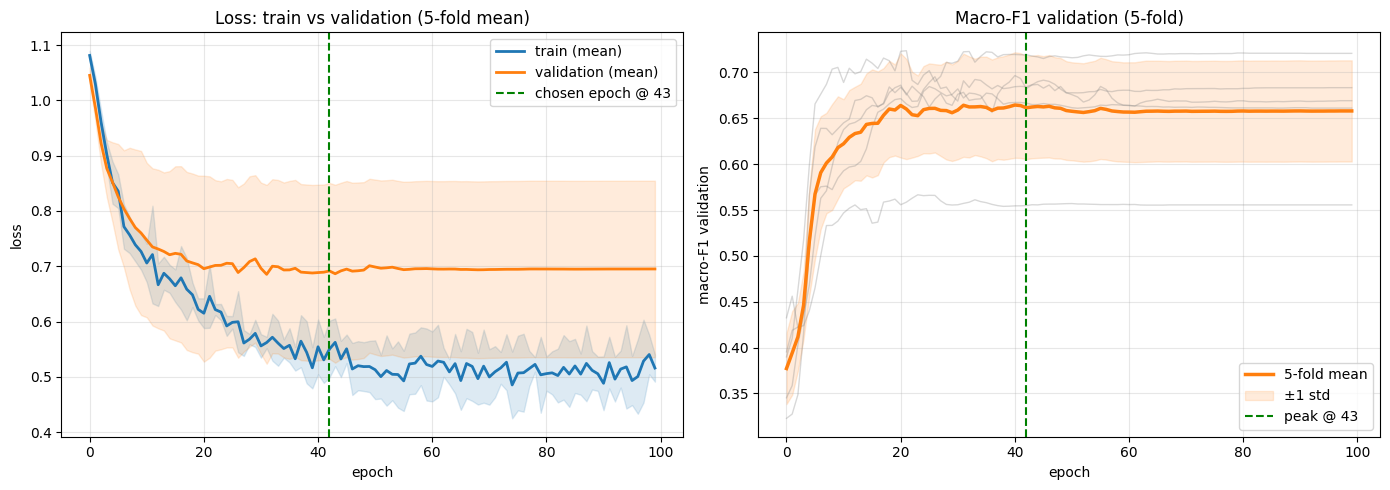

Train-val loss gap at the plateau (final epoch): 0.179
Train-val loss gap at the chosen epoch (43): 0.141


In [21]:
tr_mean, tr_std = train_loss_curves.mean(0), train_loss_curves.std(0)
vl_mean, vl_std = val_loss_curves.mean(0),   val_loss_curves.std(0)
f1_mean, f1_std = val_f1_curves.mean(0),     val_f1_curves.std(0)
x = range(len(tr_mean))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT panel: LOSS ---
ax[0].plot(x, tr_mean, color="C0", lw=2, label="train (mean)")
ax[0].fill_between(x, tr_mean-tr_std, tr_mean+tr_std, color="C0", alpha=0.15)
ax[0].plot(x, vl_mean, color="C1", lw=2, label="validation (mean)")
ax[0].fill_between(x, vl_mean-vl_std, vl_mean+vl_std, color="C1", alpha=0.15)
ax[0].axvline(BEST_EPOCHS-1, color="green", ls="--", label=f"chosen epoch @ {BEST_EPOCHS}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Loss: train vs validation (5-fold mean)")
ax[0].legend(); ax[0].grid(alpha=0.3)

# --- RIGHT panel: MACRO-F1 ---
for c in val_f1_curves:
    ax[1].plot(x, c, color="gray", alpha=0.3, lw=1)
ax[1].plot(x, f1_mean, color="C1", lw=2.5, label="5-fold mean")
ax[1].fill_between(x, f1_mean-f1_std, f1_mean+f1_std, color="C1", alpha=0.15, label="±1 std")
ax[1].axvline(BEST_EPOCHS-1, color="green", ls="--", label=f"peak @ {BEST_EPOCHS}")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("macro-F1 validation")
ax[1].set_title("Macro-F1 validation (5-fold)")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Numbers to quote in the presentation
print(f"Train-val loss gap at the plateau (final epoch): {vl_mean[-1]-tr_mean[-1]:.3f}")
print(f"Train-val loss gap at the chosen epoch ({BEST_EPOCHS}): "
      f"{vl_mean[BEST_EPOCHS-1]-tr_mean[BEST_EPOCHS-1]:.3f}")

***LOSO STRATEGY***

In [22]:
def decision_with_weights(proba, weights):
    """Decision = argmax of the reweighted probabilities. weights[k] raises/lowers
    the implicit 'threshold' of class k (high weight = more probability needed)."""
    return np.argmax(proba / weights, axis=1)

def find_best_weights(y_true, proba, n_grid=21):
    """Grid-search the Wake/REM weights that maximize the macro-F1.
    NREM stays at 1.0 as the reference (reweighting the two rare classes is enough)."""
    grid = np.linspace(0.3, 3.0, n_grid)
    best_f1, best_w = -1, np.array([1.0, 1.0, 1.0])
    for w_wake in grid:
        for w_rem in grid:
            w = np.array([w_wake, 1.0, w_rem])   # [Wake, NREM, REM]
            f1 = f1_score(y_true, decision_with_weights(proba, w),
                          average="macro", zero_division=0)
            if f1 > best_f1:
                best_f1, best_w = f1, w
    return best_w, best_f1

***BiLSTM***

In [23]:
all_ids_list = features_clean["subject_id"].unique().tolist()
fold_results = []

print(f"Starting LOSO: {len(all_ids_list)} fold\n")

for i, test_id in enumerate(all_ids_list):
    train_ids_fold = [s for s in all_ids_list if s != test_id]
    
    print(f"Fold {i+1:2d}/{len(all_ids_list)} | Test: {test_id}")
    
    result = train_one_fold(
        train_ids   = train_ids_fold,
        test_id     = test_id,
        df          = features_clean,
        n_epochs    = 43,
        patience    = 5
    )
    fold_results.append(result)
    print(f"  → macro-F1: {result['macro_f1']:.3f} | "
          f"κ: {result['kappa']:.3f} | ")

# Aggregated results
macro_f1s = [r["macro_f1"] for r in fold_results]
kappas    = [r["kappa"]    for r in fold_results]

print("=" * 45)
print("FINAL LOSO RESULTS")
print("=" * 45)
print(f"Macro-F1:    {np.mean(macro_f1s):.3f} ± {np.std(macro_f1s):.3f}")
print(f"Cohen's κ:   {np.mean(kappas):.3f} ± {np.std(kappas):.3f}")

# Confusion matrix aggregated over all folds
y_true_all = np.concatenate([r["y_true"] for r in fold_results])
y_pred_all = np.concatenate([r["y_pred"] for r in fold_results])

print(f"\nConfusion Matrix (LOSO aggregated):")
cm = confusion_matrix(y_true_all, y_pred_all)
cm_df = pd.DataFrame(cm, 
                      index=["True Wake","True NREM","True REM"],
                      columns=["Pred Wake","Pred NREM","Pred REM"])
print(cm_df)
print(f"\nClassification Report:")
print(classification_report(y_true_all, y_pred_all,
                             target_names=["Wake","NREM","REM"]))

Starting LOSO: 31 fold

Fold  1/31 | Test: 1066528
  Class weights: Wake=1.94, NREM=0.69, REM=1.23
  Epoch  15/43 | Loss: 0.6444 | LR: 0.001000
  Epoch  30/43 | Loss: 0.5382 | LR: 0.001000
  → macro-F1: 0.763 | κ: 0.668 | 
Fold  2/31 | Test: 1360686
  Class weights: Wake=1.92, NREM=0.70, REM=1.22
  Epoch  15/43 | Loss: 0.6368 | LR: 0.001000
  Epoch  30/43 | Loss: 0.5224 | LR: 0.001000
  → macro-F1: 0.607 | κ: 0.434 | 
Fold  3/31 | Test: 1449548
  Class weights: Wake=1.91, NREM=0.70, REM=1.22
  Epoch  15/43 | Loss: 0.6284 | LR: 0.001000
  Epoch  30/43 | Loss: 0.5383 | LR: 0.001000
  → macro-F1: 0.728 | κ: 0.669 | 
Fold  4/31 | Test: 1455390
  Class weights: Wake=1.90, NREM=0.70, REM=1.22
  Epoch  15/43 | Loss: 0.6327 | LR: 0.001000
  Epoch  30/43 | Loss: 0.5207 | LR: 0.001000
  → macro-F1: 0.666 | κ: 0.519 | 
Fold  5/31 | Test: 1818471
  Class weights: Wake=1.87, NREM=0.70, REM=1.22
  Epoch  15/43 | Loss: 0.6374 | LR: 0.001000
  Epoch  30/43 | Loss: 0.5250 | LR: 0.001000
  → macro-F1: 0

Internal probabilities (LOSO): (26417, 3)
--- Walch (internal LOSO) ---
  Wake : AUC=0.863 | AP=0.558 | optimal threshold=0.153 | prevalence=0.092
  NREM : AUC=0.831 | AP=0.911 | optimal threshold=0.565 | prevalence=0.685
  REM  : AUC=0.859 | AP=0.616 | optimal threshold=0.187 | prevalence=0.223


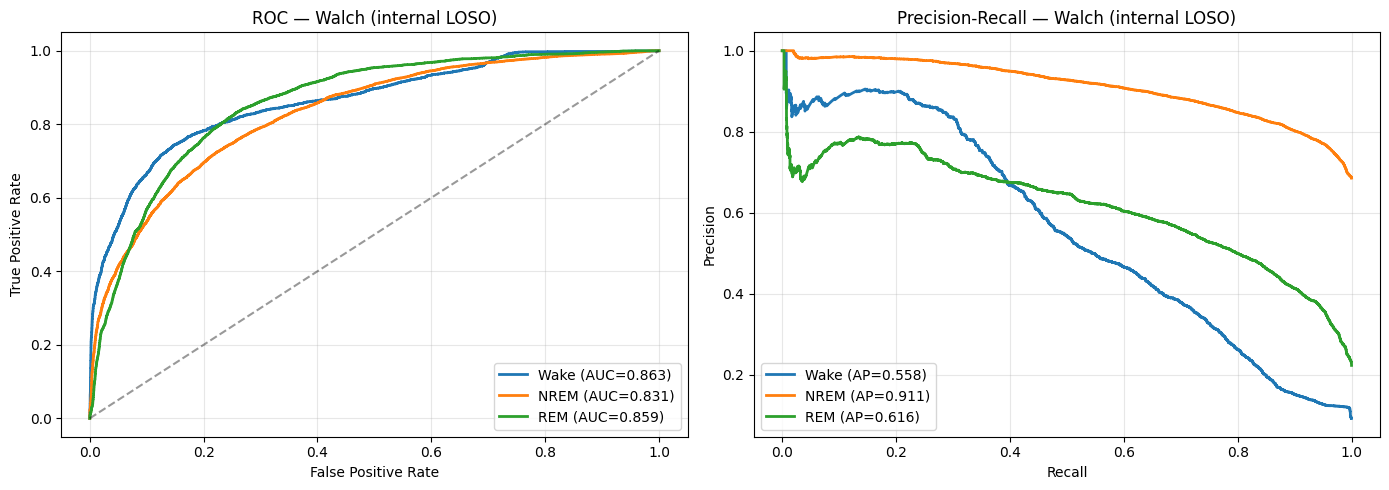

In [24]:
# Concatenate the probabilities of all the LOSO held-out subjects
y_true_int  = np.concatenate([r["y_true"]  for r in fold_results])
y_proba_int = np.concatenate([r["y_proba"] for r in fold_results])
print("Internal probabilities (LOSO):", y_proba_int.shape)

# Same function used for DREAMT
plot_roc_pr(y_true_int, y_proba_int, title="Walch (internal LOSO)")

In [25]:
# STEP 1: find the weights on the internal VALIDATION set (Walch LOSO probabilities)
best_w_lstm, f1_val = find_best_weights(y_true_int, y_proba_int)
print(f"Optimal weights [Wake, NREM, REM]: {best_w_lstm} | F1 validation: {f1_val:.3f}")

# Predictions under the two scenarios
pred_default = np.argmax(y_proba_int, axis=1)                    # standard argmax
pred_weighted = decision_with_weights(y_proba_int, best_w_lstm)  # reweighted

# F1 and κ for both
f1_default = f1_score(y_true_int, pred_default, average="macro", zero_division=0)
k_default  = cohen_kappa_score(y_true_int, pred_default)
k_weighted = cohen_kappa_score(y_true_int, pred_weighted)

print(f"F1 standard argmax: {f1_default:.3f} -> reweighted: {f1_val:.3f}")
print(f"κ  standard argmax: {k_default:.3f} -> reweighted: {k_weighted:.3f}")

Optimal weights [Wake, NREM, REM]: [3.    1.    1.245] | F1 validation: 0.658
F1 standard argmax: 0.652 -> reweighted: 0.658
κ  standard argmax: 0.479 -> reweighted: 0.487


In [26]:
#Temperature scaling: needed to soften the output probabilities, which the model makes "aggressive". Applying it is what allows us to say
#                     that the model is X% confident about the classification of a class.

def expected_calibration_error(y_true, proba, n_bins=10):
    """ECE: mean distance between stated confidence and actual accuracy.
    0 = perfectly calibrated; high = over/under-confident."""
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    acc  = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            ece += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return ece

def nll(y_true, proba):
    p = proba[np.arange(len(y_true)), y_true]
    return -np.log(np.clip(p, 1e-12, 1)).mean()

def apply_temperature(proba, T):
    """softmax(log(proba)/T). T>1 softens, T<1 sharpens. argmax unchanged."""
    logits = np.log(np.clip(proba, 1e-12, 1))
    z = logits / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# Find the T that minimizes the cross-entropy on the VALIDATION set (internal LOSO = no leakage)
Ts = np.linspace(0.5, 5.0, 91)
best_T = min(Ts, key=lambda T: nll(y_true_int, apply_temperature(y_proba_int, T)))
print(f"Optimal temperature T = {best_T:.2f}")

proba_int_T = apply_temperature(y_proba_int, best_T)
print(f"ECE before: {expected_calibration_error(y_true_int, y_proba_int):.4f}")
print(f"ECE after : {expected_calibration_error(y_true_int, proba_int_T):.4f}")
print(f"F1  before: {f1_score(y_true_int, y_proba_int.argmax(1), average='macro'):.4f}")
print(f"F1  after : {f1_score(y_true_int, proba_int_T.argmax(1), average='macro'):.4f}  <- identical, as expected")

Optimal temperature T = 1.45
ECE before: 0.0929
ECE after : 0.0279
F1  before: 0.6518
F1  after : 0.6518  <- identical, as expected


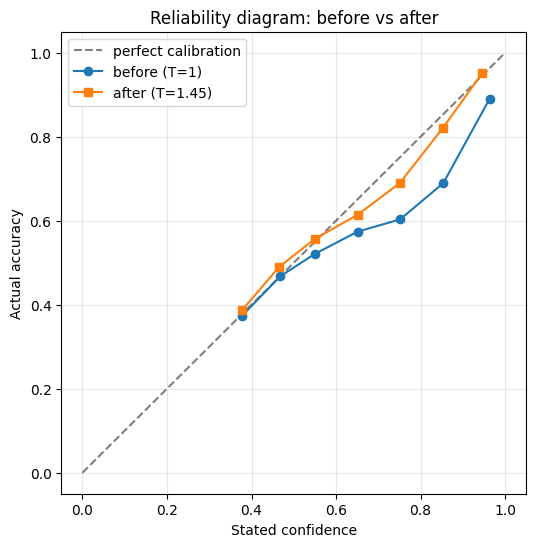

In [27]:
def reliability_points(y_true, proba, n_bins=10):
    conf = proba.max(axis=1); pred = proba.argmax(axis=1)
    acc  = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            xs.append(conf[m].mean()); ys.append(acc[m].mean())
    return xs, ys

x0, y0 = reliability_points(y_true_int, y_proba_int)                       # before
x1, y1 = reliability_points(y_true_int, apply_temperature(y_proba_int, best_T))  # after

plt.figure(figsize=(6, 6))
plt.plot([0,1],[0,1], "k--", alpha=0.5, label="perfect calibration")
plt.plot(x0, y0, "o-", label="before (T=1)")
plt.plot(x1, y1, "s-", label=f"after (T={best_T:.2f})")
plt.xlabel("Stated confidence"); plt.ylabel("Actual accuracy")
plt.title("Reliability diagram: before vs after"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [28]:
analysis = []
for r in fold_results:
    sid  = r["subject_id"]
    subj = features_clean[features_clean["subject_id"] == sid]
    total    = len(subj)
    wake_pct = (subj["label"] == 0).sum() / total
    nrem_pct = (subj["label"] == 1).sum() / total
    rem_pct  = (subj["label"] == 2).sum() / total
    analysis.append({
        "subject_id" : sid,
        "macro_f1"   : r["macro_f1"],
        "kappa"      : r["kappa"],
        "wake_pct"   : round(wake_pct * 100, 1),
        "nrem_pct"   : round(nrem_pct * 100, 1),
        "rem_pct"    : round(rem_pct  * 100, 1),
        "n_epochs"   : total,
    })

df_analysis = pd.DataFrame(analysis).sort_values("macro_f1")

print("Worst subjects (F1 < 0.60):")
print(df_analysis[df_analysis["macro_f1"] < 0.60][
    ["subject_id","macro_f1","kappa","wake_pct","nrem_pct",
     "rem_pct","n_epochs"]].to_string(index=False))

print("\nBest subjects (F1 > 0.75):")
print(df_analysis[df_analysis["macro_f1"] > 0.75][
    ["subject_id","macro_f1","kappa","wake_pct","nrem_pct",
     "rem_pct","n_epochs"]].to_string(index=False))

print("\nCorrelation with macro-F1:")
for col in ["wake_pct","nrem_pct","rem_pct","n_epochs"]:
    corr = df_analysis["macro_f1"].corr(df_analysis[col])
    print(f"  {col:12s}: r = {corr:+.3f}")

Worst subjects (F1 < 0.60):
 subject_id  macro_f1    kappa  wake_pct  nrem_pct  rem_pct  n_epochs
    7749105  0.335771 0.076315      21.7      55.2     23.1       945
    9106476  0.446074 0.212967       9.1      81.8      9.2       961
    3997827  0.452803 0.177931       2.6      66.8     30.6       958
    2598705  0.496535 0.307208       2.1      71.6     26.3       954
     844359  0.516356 0.249889      10.4      67.4     22.2       897
    5132496  0.523179 0.347784       7.1      92.9      0.0       465
    8692923  0.551110 0.223707      11.8      66.1     22.1       936
    5797046  0.575580 0.425407       8.4      75.8     15.8       939
    3509524  0.595633 0.330671      12.7      75.8     11.5       417

Best subjects (F1 > 0.75):
 subject_id  macro_f1    kappa  wake_pct  nrem_pct  rem_pct  n_epochs
    1066528  0.762523 0.667578      19.4      48.1     32.5       952
    8530312  0.767331 0.672520       8.2      64.0     27.8       947
    4018081  0.784239 0.704839    

In [29]:
# Global mean distribution (approximation of the training set)
global_wake = features_clean["label"].eq(0).mean()
global_nrem = features_clean["label"].eq(1).mean()
global_rem  = features_clean["label"].eq(2).mean()

print(f"Mean training distribution:")
print(f"  Wake: {global_wake:.3f}  NREM: {global_nrem:.3f}  REM: {global_rem:.3f}")

# For each subject, compute the distance from the mean distribution
for row in analysis:
    wake_dev = abs(row["wake_pct"]/100 - global_wake)
    nrem_dev = abs(row["nrem_pct"]/100 - global_nrem)
    rem_dev  = abs(row["rem_pct"] /100 - global_rem)
    # L1 distance from the mean distribution
    row["dist_from_mean"] = wake_dev + nrem_dev + rem_dev

df_analysis = pd.DataFrame(analysis)
corr_dist = df_analysis["macro_f1"].corr(df_analysis["dist_from_mean"])

print(f"\nCorrelation F1 vs distance from the mean distribution:")
print(f"  r = {corr_dist:+.3f}")

print(f"\nSubjects sorted by distance from the mean:")
print(df_analysis.sort_values("dist_from_mean", ascending=False)[
    ["subject_id","macro_f1","wake_pct","nrem_pct",
     "rem_pct","dist_from_mean"]].to_string(index=False))

Mean training distribution:
  Wake: 0.092  NREM: 0.685  REM: 0.223

Correlation F1 vs distance from the mean distribution:
  r = -0.127

Subjects sorted by distance from the mean:
 subject_id  macro_f1  wake_pct  nrem_pct  rem_pct  dist_from_mean
    5132496  0.523179       7.1      92.9      0.0        0.487367
    1066528  0.762523      19.4      48.1     32.5        0.408633
    4018081  0.784239      17.8      75.3      6.9        0.307471
    7749105  0.335771      21.7      55.2     23.1        0.266633
    9106476  0.446074       9.1      81.8      9.2        0.264367
    8258170  0.700976      10.7      55.9     33.4        0.252633
    5383425  0.608813       5.1      60.7     34.2        0.238529
     759667  0.832610       3.8      62.3     33.9        0.232529
    6220552  0.613065       5.5      79.7     14.8        0.223367
    3509524  0.595633      12.7      75.8     11.5        0.215471
    8686948  0.678803       5.1      78.2     16.6        0.194367
    5498603  0.6

***RANDOM FOREST***

In [30]:
def train_rf_fold(train_ids, test_id, df, n_estimators=300):
    """
    Random Forest with LOSO.
    Each epoch is classified independently — no temporal information
    between consecutive epochs (unlike the LSTM).
    """
    train_df = df[df["subject_id"].isin(train_ids)]
    test_df  = df[df["subject_id"] == test_id]

    X_train = train_df[FEATURE_COLS].to_numpy()
    y_train = train_df["label"].to_numpy()
    X_test  = test_df[FEATURE_COLS].to_numpy()
    y_test  = test_df["label"].to_numpy()

    # class_weight="balanced" is the RF equivalent of our class weights
    # it automatically computes weights inversely proportional to frequency
    rf = RandomForestClassifier(
        n_estimators = n_estimators,
        max_depth    = None,       # deep trees: they capture complex patterns
        min_samples_leaf = 5,      # avoids overfitting on leaves with few samples
        class_weight = "balanced",
        random_state = SEED,
        n_jobs       = -1,         # use all available cores
    )

    rf.fit(X_train, y_train)
    if test_id == all_ids_list[0]:      # print only on the first fold
        print("RF class order:", rf.classes_)
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)   # shape (n_samples, 3)

    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    kappa    = cohen_kappa_score(y_test, y_pred)

    return {
        "subject_id" : test_id,
        "macro_f1"   : macro_f1,
        "kappa"      : kappa,
        "y_true"     : y_test,
        "y_pred"     : y_pred,
        "y_proba"    : y_proba
    }

# LOSO RF
fold_results_rf = []
print(f"Starting LOSO Random Forest\n")

for i, test_id in enumerate(all_ids_list):
    train_ids_fold = [s for s in all_ids_list if s != test_id]
    result = train_rf_fold(train_ids_fold, test_id, features_clean)
    fold_results_rf.append(result)
    print(f"Fold {i+1:2d}/31 | Test: {test_id:10} | "
          f"F1: {result['macro_f1']:.3f} | κ: {result['kappa']:.3f}")

# Aggregated results
macro_f1s_rf = [r["macro_f1"] for r in fold_results_rf]
kappas_rf    = [r["kappa"]    for r in fold_results_rf]

print(f"\n{'='*55}")
print(f"FINAL COMPARISON: RF vs LSTM")
print(f"{'='*55}")
print(f"{'':15s} {'Macro-F1':>18s} {'Cohen κ':>18s}")
print(f"{'LSTM v':15s}  "
      f"{np.mean(macro_f1s):.3f} ±{np.std(macro_f1s):.3f}   "
      f"{np.mean(kappas):.3f} ±{np.std(kappas):.3f}")
print(f"{'Random Forest':15s}  "
      f"{np.mean(macro_f1s_rf):.3f} ±{np.std(macro_f1s_rf):.3f}   "
      f"{np.mean(kappas_rf):.3f} ±{np.std(kappas_rf):.3f}")

# Confusion matrix RF
y_true_rf = np.concatenate([r["y_true"] for r in fold_results_rf])
y_pred_rf = np.concatenate([r["y_pred"] for r in fold_results_rf])
y_proba_rf = np.concatenate([r["y_proba"] for r in fold_results_rf])

print(f"\n\nConfusion Matrix RF:")
cm_rf = confusion_matrix(y_true_rf, y_pred_rf)
print(pd.DataFrame(cm_rf,
                   index=["True Wake","True NREM","True REM"],
                   columns=["Pred Wake","Pred NREM","Pred REM"]))
print(f"\nClassification Report RF:")
print(classification_report(y_true_rf, y_pred_rf,
                            target_names=["Wake","NREM","REM"]))

Starting LOSO Random Forest

RF class order: [0 1 2]
Fold  1/31 | Test:    1066528 | F1: 0.584 | κ: 0.405
Fold  2/31 | Test:    1360686 | F1: 0.682 | κ: 0.523
Fold  3/31 | Test:    1449548 | F1: 0.689 | κ: 0.577
Fold  4/31 | Test:    1455390 | F1: 0.562 | κ: 0.277
Fold  5/31 | Test:    1818471 | F1: 0.481 | κ: 0.289
Fold  6/31 | Test:    2598705 | F1: 0.497 | κ: 0.279
Fold  7/31 | Test:    2638030 | F1: 0.811 | κ: 0.740
Fold  8/31 | Test:    3509524 | F1: 0.587 | κ: 0.333
Fold  9/31 | Test:    3997827 | F1: 0.537 | κ: 0.309
Fold 10/31 | Test:    4018081 | F1: 0.536 | κ: 0.330
Fold 11/31 | Test:    4314139 | F1: 0.633 | κ: 0.398
Fold 12/31 | Test:    4426783 | F1: 0.751 | κ: 0.629
Fold 13/31 | Test:      46343 | F1: 0.575 | κ: 0.346
Fold 14/31 | Test:    5132496 | F1: 0.556 | κ: 0.461
Fold 15/31 | Test:    5383425 | F1: 0.532 | κ: 0.144
Fold 16/31 | Test:    5498603 | F1: 0.626 | κ: 0.453
Fold 17/31 | Test:    5797046 | F1: 0.609 | κ: 0.436
Fold 18/31 | Test:    6220552 | F1: 0.585 | κ:

--- Random Forest (internal LOSO) ---
  Wake : AUC=0.843 | AP=0.540 | optimal threshold=0.251 | prevalence=0.092
  NREM : AUC=0.792 | AP=0.888 | optimal threshold=0.491 | prevalence=0.685
  REM  : AUC=0.797 | AP=0.525 | optimal threshold=0.303 | prevalence=0.223


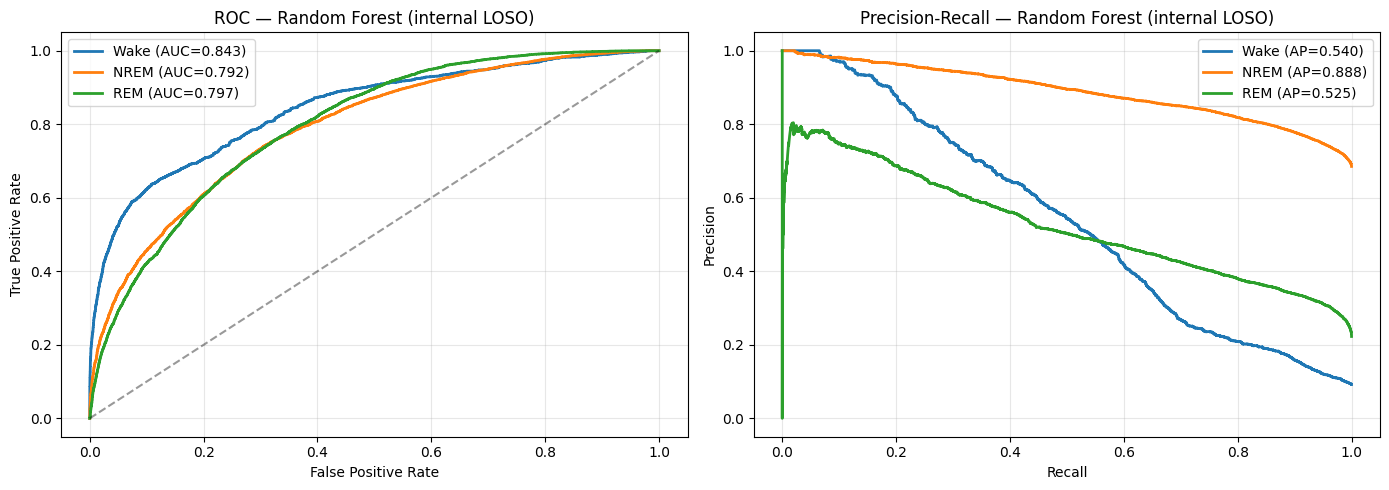

Optimal weights [Wake, NREM, REM]: [1.245 1.    0.975] | F1 validation: 0.615
F1 standard argmax: 0.612 -> reweighted: 0.615


In [31]:
plot_roc_pr(y_true_rf, y_proba_rf, title="Random Forest (internal LOSO)")

# STEP 1: find the weights on the internal VALIDATION set (Walch LOSO probabilities)
best_w_rf, f1_val = find_best_weights(y_true_rf, y_proba_rf)
print(f"Optimal weights [Wake, NREM, REM]: {best_w_rf} | F1 validation: {f1_val:.3f}")

# Comparison: standard argmax vs reweighted, ON THE VALIDATION SET
f1_default = f1_score(y_true_rf, np.argmax(y_proba_rf, axis=1),
                      average="macro", zero_division=0)
print(f"F1 standard argmax: {f1_default:.3f} -> reweighted: {f1_val:.3f}")

In [32]:
# Feature importance — what the RF uses to classify
importances = np.zeros(len(FEATURE_COLS))
# mean of the importances over all folds (we did not save the models,
# so we compute it on a representative fit)
rf_final = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                   class_weight="balanced",
                                   random_state=SEED, n_jobs=-1)
rf_final.fit(features_clean[FEATURE_COLS], features_clean["label"])
importances = rf_final.feature_importances_

print(f"\nFeature Importance (RF trained on all subjects):")
fi_df = pd.DataFrame({
    "feature"    : FEATURE_COLS,
    "importance" : importances
}).sort_values("importance", ascending=False)
for _, row in fi_df.iterrows():
    bar = "█" * int(row["importance"] * 100)
    print(f"  {row['feature']:15s}: {row['importance']:.3f}  {bar}")


Feature Importance (RF trained on all subjects):
  epoch_progress : 0.207  ████████████████████
  enmo_std_roll5 : 0.092  █████████
  angle_std      : 0.074  ███████
  hr_std_roll5   : 0.073  ███████
  hr_mean_roll5  : 0.057  █████
  angle_mean     : 0.056  █████
  enmo_mean_roll5: 0.053  █████
  angle_delta    : 0.051  █████
  acc_mag_std    : 0.050  ████
  acc_count      : 0.046  ████
  hr_max         : 0.042  ████
  enmo_mean      : 0.041  ████
  enmo_std       : 0.041  ████
  hr_mean        : 0.033  ███
  hr_min         : 0.028  ██
  hr_std         : 0.020  ██
  hr_range       : 0.019  █
  hr_mssd        : 0.018  █


***FINAL TRAINING***

In [ ]:
# Fixed number of epochs = median stopping epoch across LOSO folds
FINAL_EPOCHS = 43

# Padding that covers the longest night of BOTH datasets
MAX_LEN = int(max(
    features_clean.groupby("subject_id").size().max(),
    dreamt_clean.groupby("subject_id").size().max(),
))

def train_final_model(train_df, train_ids, max_len, n_epochs, lr=1e-3, hidden_size=64):
    """ONE model on ALL train_ids, for a fixed n_epochs. Same procedure as LOSO,
    only without leaving any subject out"""
    loader    = DataLoader(NightSequenceDataset(train_df, train_ids, max_len),
                           batch_size=8, shuffle=True)
    model     = SleepLSTM(N_FEATURES, N_CLASSES, hidden_size=hidden_size).to(DEVICE)
    weights   = compute_class_weights_sqrt(train_df, train_ids)
    criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)
    #criterion = FocalLoss(alpha=weights, gamma=2.0, ignore_index=-1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                           factor=0.5, patience=5)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for epoch in range(n_epochs):
        tot = 0.0
        for X_b, y_b, m_b in loader:
            X_b, y_b, m_b = X_b.to(DEVICE), y_b.to(DEVICE), m_b.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_b)
            
            B, T, C = logits.shape
            yf = y_b.view(B*T).clone(); yf[~m_b.view(B*T)] = -1
            loss = criterion(logits.view(B*T, C), yf)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot += loss.item()
            
        scheduler.step(tot / len(loader))
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | train loss {tot/len(loader):.4f}")
    return model

walch_ids   = features_clean["subject_id"].unique().tolist()
final_model = train_final_model(features_clean, walch_ids, MAX_LEN, FINAL_EPOCHS)
print(f"Final model trained on all {len(walch_ids)} Walch subjects.")

Final model epochs (LOSO median): 43
  Class weights: Wake=1.90, NREM=0.70, REM=1.22
  Epoch  20/43 | train loss 0.5959
  Epoch  40/43 | train loss 0.4886
Final model trained on all 31 Walch subjects.


In [34]:
# --- 0. Alignment check: same epochs, same order ---
assert len(y_true_int) == len(y_true_rf), "Different lengths: the two LOSO runs are not aligned!"
assert np.array_equal(y_true_int, y_true_rf), "Labels do not match: different subject order!"
y_true = y_true_int   # they are identical, either one works

# --- 1. Search for the weight w that maximizes macro-F1 on the VALIDATION set (LOSO) ---
best_w_ens, best_f1 = 0.5, -1
for w in np.linspace(0, 1, 18):           # from 0 (RF only) to 1 (LSTM only)
    proba_ens = w * y_proba_int + (1 - w) * y_proba_rf
    f1 = f1_score(y_true, proba_ens.argmax(1), average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1, best_w_ens = f1, w

print(f"Optimal weight w (LSTM) = {best_w_ens:.2f}  ->  RF gets {1-best_w_ens:.2f}")

# --- 2. Comparison: single models vs ensemble, on the same validation set ---
f1_lstm = f1_score(y_true, y_proba_int.argmax(1), average="macro", zero_division=0)
f1_rf   = f1_score(y_true, y_proba_rf.argmax(1),  average="macro", zero_division=0)
proba_ens = best_w_ens * y_proba_int + (1 - best_w_ens) * y_proba_rf
f1_ens = f1_score(y_true, proba_ens.argmax(1), average="macro", zero_division=0)
k_ens  = cohen_kappa_score(y_true, proba_ens.argmax(1))

print(f"\n{'Model':20s} {'macro-F1':>9s}")
print(f"{'LSTM alone':20s} {f1_lstm:>9.3f}")
print(f"{'RF alone':20s} {f1_rf:>9.3f}")
print(f"{'Ensemble':20s} {f1_ens:>9.3f}   (κ={k_ens:.3f})")

Optimal weight w (LSTM) = 0.47  ->  RF gets 0.53

Model                 macro-F1
LSTM alone               0.652
RF alone                 0.612
Ensemble                 0.668   (κ=0.495)


***CROSS-DATASET VALIDATION***

In [35]:
def evaluate_external(model, df, ids, max_len):
    loader = DataLoader(NightSequenceDataset(df, ids, max_len),
                        batch_size=8, shuffle=False)
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for X_b, y_b, m_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=-1)
            for i in range(len(X_b)):
                m = m_b[i].numpy()
                yp.extend(preds[i].cpu().numpy()[m])
                yt.extend(y_b[i].numpy()[m])
    return np.array(yt), np.array(yp)

dreamt_ids = dreamt_clean["subject_id"].unique().tolist()
y_true_ext, y_pred_ext = evaluate_external(final_model, dreamt_clean, dreamt_ids, MAX_LEN)

ext_f1    = f1_score(y_true_ext, y_pred_ext, average="macro", zero_division=0)
ext_kappa = cohen_kappa_score(y_true_ext, y_pred_ext)
int_f1    = np.mean([r["macro_f1"] for r in fold_results])   # from the Walch LOSO
int_kappa = np.mean([r["kappa"]    for r in fold_results])

print("="*52)
print("INTERNAL (Walch LOSO)  vs  EXTERNAL (DREAMT)")
print("="*52)
print(f"                  macro-F1      kappa")
print(f"Internal (LOSO)    {int_f1:6.3f}     {int_kappa:6.3f}")
print(f"External (DREAMT)  {ext_f1:6.3f}     {ext_kappa:6.3f}")
print(f"DROP (shift)       {int_f1-ext_f1:+6.3f}     {int_kappa-ext_kappa:+6.3f}")
print()
print(classification_report(y_true_ext, y_pred_ext,
                            target_names=["Wake","NREM","REM"], zero_division=0))
print("Confusion matrix DREAMT:")
print(pd.DataFrame(confusion_matrix(y_true_ext, y_pred_ext),
                   index=["True Wake","True NREM","True REM"],
                   columns=["Pred Wake","Pred NREM","Pred REM"]))

INTERNAL (Walch LOSO)  vs  EXTERNAL (DREAMT)
                  macro-F1      kappa
Internal (LOSO)     0.644      0.480
External (DREAMT)   0.563      0.368
DROP (shift)       +0.081     +0.112

              precision    recall  f1-score   support

        Wake       0.65      0.48      0.55     20060
        NREM       0.76      0.83      0.79     51820
         REM       0.33      0.36      0.35      8417

    accuracy                           0.69     80297
   macro avg       0.58      0.56      0.56     80297
weighted avg       0.69      0.69      0.68     80297

Confusion matrix DREAMT:
           Pred Wake  Pred NREM  Pred REM
True Wake       9653       8811      1596
True NREM       4539      42756      4525
True REM         669       4715      3033


In [36]:
def predict_proba(model, df, ids, max_len):
    """Returns (y_true, y_proba). y_proba has shape (N, 3): per-class softmax."""
    loader = DataLoader(NightSequenceDataset(df, ids, max_len), batch_size=8, shuffle=False)
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for X_b, y_b, m_b in loader:
            proba = F.softmax(model(X_b.to(DEVICE)), dim=-1)   # (B, T, 3)
            for i in range(len(X_b)):
                m = m_b[i].numpy()
                yp.append(proba[i].cpu().numpy()[m])
                yt.append(y_b[i].numpy()[m])
    return np.concatenate(yt), np.concatenate(yp)

y_true_ext, y_proba_ext = predict_proba(final_model, dreamt_clean, dreamt_ids, MAX_LEN)
print("DREAMT probabilities:", y_proba_ext.shape)   # expected (80297, 3)

DREAMT probabilities: (80297, 3)


--- DREAMT (external test) ---
  Wake : AUC=0.800 | AP=0.627 | optimal threshold=0.074 | prevalence=0.250
  NREM : AUC=0.756 | AP=0.838 | optimal threshold=0.740 | prevalence=0.645
  REM  : AUC=0.748 | AP=0.297 | optimal threshold=0.074 | prevalence=0.105


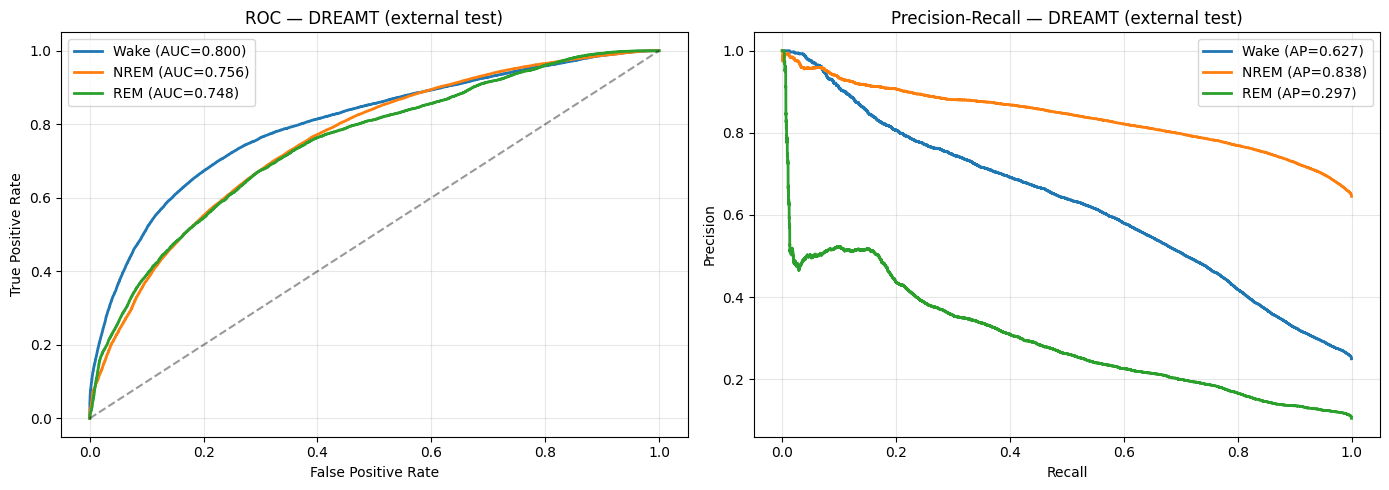

In [37]:
plot_roc_pr(y_true_ext, y_proba_ext, title="DREAMT (external test)")

In [38]:
# STEP 3: apply the SAME weights to the external DREAMT test (without re-searching them!)
y_pred_ext_def = np.argmax(y_proba_ext, axis=1)
y_pred_ext_cal = decision_with_weights(y_proba_ext, best_w_lstm)
print("DREAMT standard:", f1_score(y_true_ext, y_pred_ext_def, average='macro', zero_division=0))
print("DREAMT recalibrated:", f1_score(y_true_ext, y_pred_ext_cal, average='macro', zero_division=0))

DREAMT standard: 0.5630354940711175
DREAMT recalibrated: 0.5422875153842776


In [39]:
def metrics_pair(y_true, proba, weights):
    pred_def = np.argmax(proba, axis=1)
    pred_cal = np.argmax(proba / weights, axis=1)
    return {
        "f1_def": f1_score(y_true, pred_def, average="macro", zero_division=0),
        "k_def" : cohen_kappa_score(y_true, pred_def),
        "f1_cal": f1_score(y_true, pred_cal, average="macro", zero_division=0),
        "k_cal" : cohen_kappa_score(y_true, pred_cal),
    }

m_int = metrics_pair(y_true_int, y_proba_int, best_w_lstm)   # internal Walch LOSO
m_ext = metrics_pair(y_true_ext, y_proba_ext, best_w_lstm)   # external DREAMT

print(f"{'':24s} {'macro-F1':>9s} {'kappa':>8s}")
print(f"{'Walch  std argmax':24s} {m_int['f1_def']:>9.3f} {m_int['k_def']:>8.3f}   <- comparison with the paper")
print(f"{'Walch  recalibrated':24s} {m_int['f1_cal']:>9.3f} {m_int['k_cal']:>8.3f}")
print(f"{'DREAMT std argmax':24s} {m_ext['f1_def']:>9.3f} {m_ext['k_def']:>8.3f}")
print(f"{'DREAMT recalibrated':24s} {m_ext['f1_cal']:>9.3f} {m_ext['k_cal']:>8.3f}")

                          macro-F1    kappa
Walch  std argmax            0.652    0.479   <- comparison with the paper
Walch  recalibrated          0.658    0.487
DREAMT std argmax            0.563    0.368
DREAMT recalibrated          0.542    0.333


In [40]:
# 1. RF trained on the whole Walch dataset
rf_final = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                  class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_final.fit(features_clean[FEATURE_COLS], features_clean["label"])

# 2. Build LSTM-proba and RF-proba on the same epochs, subject by subject,
#    in the SAME order -> alignment guaranteed

lstm_probas, rf_probas, true_labels = [], [], []
final_model.eval()
for sid in dreamt_ids:                      # same order for both
    subj = dreamt_clean[dreamt_clean["subject_id"] == sid].sort_values("epoch")
    X = subj[FEATURE_COLS].to_numpy()
    y = subj["label"].to_numpy()

    # RF: row by row, order = that of subj
    rf_probas.append(rf_final.predict_proba(subj[FEATURE_COLS]))

    # LSTM: one night, no padding (one subject at a time)
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1, T, F)
        p  = F.softmax(final_model(xb), dim=-1)[0].cpu().numpy()           # (T, 3)
    lstm_probas.append(p)
    true_labels.append(y)

lstm_ext = np.concatenate(lstm_probas)
rf_ext   = np.concatenate(rf_probas)
y_ext    = np.concatenate(true_labels)

# 3. Apply the SAME best_w found on the internal validation (do NOT re-optimize on DREAMT!)
proba_ens_ext = best_w_ens * lstm_ext + (1 - best_w_ens) * rf_ext

print(f"{'LSTM external':18s} F1={f1_score(y_ext, lstm_ext.argmax(1), average='macro', zero_division=0):.3f}")
print(f"{'RF external':18s} F1={f1_score(y_ext, rf_ext.argmax(1), average='macro', zero_division=0):.3f}")
print(f"{'Ensemble external':18s} F1={f1_score(y_ext, proba_ens_ext.argmax(1), average='macro', zero_division=0):.3f} "
      f"κ={cohen_kappa_score(y_ext, proba_ens_ext.argmax(1)):.3f}")

LSTM external      F1=0.563
RF external        F1=0.507
Ensemble external  F1=0.555 κ=0.358


***PRE_TRAINING AND FINE-TUNING***

In [41]:
dreamt_ids_all = dreamt_clean["subject_id"].unique().tolist()
ft_ids, test_ids_dreamt = train_test_split(dreamt_ids_all, test_size=0.5, random_state=42)
print(f"Fine-tuning: {len(ft_ids)} subjects | Test: {len(test_ids_dreamt)} subjects")

MAX_LEN = int(max(
    features_clean.groupby("subject_id").size().max(),
    dreamt_clean.groupby("subject_id").size().max(),
))

Fine-tuning: 50 subjects | Test: 50 subjects


In [42]:
# This is the starting point: final_model has NEVER seen DREAMT.
# We test it on the test subjects, so we get the "before".
y_true_base, y_pred_base = evaluate_external(final_model, dreamt_clean, test_ids_dreamt, MAX_LEN)
f1_base = f1_score(y_true_base, y_pred_base, average="macro", zero_division=0)
k_base  = cohen_kappa_score(y_true_base, y_pred_base)
print(f"BASELINE (Walch only) on the DREAMT test: macro-F1={f1_base:.3f} | κ={k_base:.3f}")

BASELINE (Walch only) on the DREAMT test: macro-F1=0.546 | κ=0.352


In [ ]:
def fine_tune(base_model, ft_df, ft_ids, max_len, n_epochs=20, lr=5e-5):
    """Full fine-tuning of the pre-trained model on the DREAMT fine-tuning subjects.

    All parameters are updated with a low learning rate. Class weights are
    recomputed on the DREAMT label distribution.
    """
    model = copy.deepcopy(base_model).to(DEVICE)

    for p in model.parameters():
        p.requires_grad = True

    loader    = DataLoader(NightSequenceDataset(ft_df, ft_ids, max_len),
                           batch_size=8, shuffle=True)
    # The class weights are now computed on the DREAMT distribution (not Walch's):
    # this is part of why fine-tuning helps.
    weights   = compute_class_weights_sqrt(ft_df, ft_ids)
    #criterion = FocalLoss(alpha=weights, gamma=2.0, ignore_index=-1)
    criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()

    for epoch in range(n_epochs):
        tot = 0.0
        for X_b, y_b, m_b in loader:
            X_b, y_b, m_b = X_b.to(DEVICE), y_b.to(DEVICE), m_b.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_b)
            B, T, C = logits.shape
            yf = y_b.view(B*T).clone(); yf[~m_b.view(B*T)] = -1
            loss = criterion(logits.view(B*T, C), yf)
            loss.backward()
            nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
            optimizer.step()
            tot += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  FT epoch {epoch+1}/{n_epochs} | loss {tot/len(loader):.4f}")
    return model

final_model_fine_tuned = fine_tune(final_model, dreamt_clean, ft_ids, MAX_LEN, n_epochs=30, lr=5e-5)
print("Fine-tuning completed.")

  Class weights: Wake=1.14, NREM=0.72, REM=1.80
  FT epoch 5/30 | loss 0.9311
  FT epoch 10/30 | loss 0.9308
  FT epoch 15/30 | loss 0.8133
  FT epoch 20/30 | loss 0.7798
  FT epoch 25/30 | loss 0.7794
  FT epoch 30/30 | loss 0.7418
Fine-tuning completed.


In [44]:
y_true_ft, y_pred_ft = evaluate_external(final_model_fine_tuned, dreamt_clean, test_ids_dreamt, MAX_LEN)
f1_ft = f1_score(y_true_ft, y_pred_ft, average="macro", zero_division=0)
k_ft  = cohen_kappa_score(y_true_ft, y_pred_ft)

print("="*54)
print("FINE-TUNING on DREAMT — comparison on the SAME test set")
print("="*54)
print(f"{'':28s} {'macro-F1':>9s} {'kappa':>8s}")
print(f"{'Baseline (Walch only)':28s} {f1_base:>9.3f} {k_base:>8.3f}")
print(f"{'After fine-tuning':28s} {f1_ft:>9.3f} {k_ft:>8.3f}")
print(f"{'Gain':28s} {f1_ft-f1_base:>+9.3f} {k_ft-k_base:>+8.3f}")
print()
print(classification_report(y_true_ft, y_pred_ft,
                            target_names=["Wake","NREM","REM"], zero_division=0))
print("Confusion matrix (after fine-tuning):")
print(pd.DataFrame(confusion_matrix(y_true_ft, y_pred_ft),
                   index=["True Wake","True NREM","True REM"],
                   columns=["Pred Wake","Pred NREM","Pred REM"]))

FINE-TUNING on DREAMT — comparison on the SAME test set
                              macro-F1    kappa
Baseline (Walch only)            0.546    0.352
After fine-tuning                0.579    0.388
Gain                            +0.033   +0.036

              precision    recall  f1-score   support

        Wake       0.60      0.58      0.59      9867
        NREM       0.78      0.78      0.78     26349
         REM       0.36      0.38      0.37      4339

    accuracy                           0.69     40555
   macro avg       0.58      0.58      0.58     40555
weighted avg       0.69      0.69      0.69     40555

Confusion matrix (after fine-tuning):
           Pred Wake  Pred NREM  Pred REM
True Wake       5708       3477       682
True NREM       3442      20581      2326
True REM         359       2320      1660


In [45]:
# ── 1. RF trained on Walch + the 50 DREAMT fine-tuning subjects ──
#    (the same subjects the LSTM sees during fine-tuning: a fair comparison)
dreamt_ft = dreamt_clean[dreamt_clean["subject_id"].isin(ft_ids)]
rf_train_X = pd.concat([features_clean[FEATURE_COLS], dreamt_ft[FEATURE_COLS]], ignore_index=True)
rf_train_y = pd.concat([features_clean["label"],      dreamt_ft["label"]],      ignore_index=True)

rf_final = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                  class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_final.fit(rf_train_X, rf_train_y)
print(f"RF trained on {len(features_clean)} epoch Walch + "
      f"{len(dreamt_ft)} epoch DREAMT (FT) = {len(rf_train_X)} total")

# ── 2. Aligned probabilities, subject by subject, same order ──
def collect_probas(lstm_model, rf_model, df, ids):
    """Returns (proba_lstm, proba_rf, y_true) aligned row by row."""
    lstm_p, rf_p, y_all = [], [], []
    lstm_model.eval()
    for sid in ids:
        subj = df[df["subject_id"] == sid].sort_values("epoch")
        Xdf  = subj[FEATURE_COLS]                 # DataFrame -> no RF warning
        y    = subj["label"].to_numpy()

        rf_p.append(rf_model.predict_proba(Xdf))  # RF: row by row

        with torch.no_grad():                     # LSTM: one night, no padding
            xb = torch.tensor(Xdf.to_numpy(), dtype=torch.float32).unsqueeze(0).to(DEVICE)
            p  = F.softmax(lstm_model(xb), dim=-1)[0].cpu().numpy()
        lstm_p.append(p)
        y_all.append(y)
    return np.concatenate(lstm_p), np.concatenate(rf_p), np.concatenate(y_all)

# Walch-only LSTM + RF
lstm_base, rf_ext, y_ext = collect_probas(final_model, rf_final, dreamt_clean, test_ids_dreamt)
# Fine-tuned LSTM (the RF is the same, and so is the alignment)
lstm_ft, _, _ = collect_probas(final_model_fine_tuned, rf_final, dreamt_clean, test_ids_dreamt)

# ── 3. Build the systems (same best_w from the internal validation, NOT re-optimized) ──
def score(name, proba):
    pred = proba.argmax(1)
    f1 = f1_score(y_ext, pred, average="macro", zero_division=0)
    k  = cohen_kappa_score(y_ext, pred)
    print(f"{name:38s} F1={f1:.3f}  κ={k:.3f}")

print("="*60)
print("SYSTEM COMPARISON on the external DREAMT test")
print("="*60)
score("1. Walch-only LSTM (baseline)",        lstm_base)
score("2. Fine-tuned LSTM",                  lstm_ft)
score("3. Walch-only RF",                     rf_ext)
score("4. Ensemble (LSTM base + RF)",         best_w_ens*lstm_base + (1-best_w_ens)*rf_ext)
score("5. Ensemble (fine-tuned LSTM + RF)",  best_w_ens*lstm_ft   + (1-best_w_ens)*rf_ext)
print(f"\n(ensemble weight: LSTM={best_w_ens:.2f}, RF={1-best_w_ens:.2f} — calibrated on the internal validation)")

RF trained on 26417 epoch Walch + 39742 epoch DREAMT (FT) = 66159 total
SYSTEM COMPARISON on the external DREAMT test
1. Walch-only LSTM (baseline)          F1=0.547  κ=0.352
2. Fine-tuned LSTM                     F1=0.580  κ=0.388
3. Walch-only RF                       F1=0.525  κ=0.322
4. Ensemble (LSTM base + RF)           F1=0.551  κ=0.367
5. Ensemble (fine-tuned LSTM + RF)     F1=0.573  κ=0.392

(ensemble weight: LSTM=0.47, RF=0.53 — calibrated on the internal validation)
